# Sinhala Buddhist Corpus: Preprocessing and Tokenization

This notebook performs comprehensive text preprocessing and tokenization for your Sinhala Buddhist corpus.

**Pipeline Overview:**
1. **Load raw corpus** from Google Drive
2. **Apply preprocessing** (cleaning, normalization, formatting)
3. **Tokenize with SinLlama** tokenizer
4. **Analyze vocabulary coverage** to determine if extension is needed
5. **Save preprocessed corpus** ready for continual pretraining

**Learning Goals:**
- Understand each preprocessing step and why it matters
- Learn how tokenization works for Sinhala
- Interpret vocabulary coverage metrics
- Make informed decisions about vocabulary extension

**Author:** Research Assistant for Multilingual Buddhist Conversational Agent  
**Date:** November 2025

## 1. Setup and Installation

In [1]:
# Install required packages
# transformers: Hugging Face library for loading pretrained models and tokenizers
# sentencepiece: Required by many tokenizers including SinLlama
!pip install --quiet transformers sentencepiece torch
!pip install --quiet pandas numpy matplotlib seaborn tqdm
!pip install --quiet google-auth google-auth-oauthlib google-auth-httplib2 google-api-python-client

In [2]:
import os
import re
import json
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Hugging Face transformers for tokenization
from transformers import AutoTokenizer

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Google Drive Authentication and File Loading

In [3]:
from google.colab import auth
from google.colab import drive

# Authenticate and mount Google Drive
auth.authenticate_user()
drive.mount('/content/drive', force_remount=True)

print("✓ Google Drive mounted successfully")

Mounted at /content/drive
✓ Google Drive mounted successfully


In [4]:
# CONFIGURATION: Update these paths to your files
RAW_CORPUS_PATH = '/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/extractions/3_final_corpus/buddhist_corpus_combined_20251101_105228.txt'
OUTPUT_DIR = '/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/'

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify input file exists
if not os.path.exists(RAW_CORPUS_PATH):
    print(f"❌ ERROR: Raw corpus not found at {RAW_CORPUS_PATH}")
    print("Please update RAW_CORPUS_PATH with the correct path.")
else:
    print(f"✓ Raw corpus found: {RAW_CORPUS_PATH}")
    file_size_mb = os.path.getsize(RAW_CORPUS_PATH) / (1024 * 1024)
    print(f"  File size: {file_size_mb:.2f} MB")
    print(f"\n✓ Output directory: {OUTPUT_DIR}")

✓ Raw corpus found: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/extractions/3_final_corpus/buddhist_corpus_combined_20251101_105228.txt
  File size: 12.90 MB

✓ Output directory: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/


In [5]:
# Load the raw corpus
def load_corpus(file_path):
    """Load corpus with proper encoding handling."""
    encodings = ['utf-8', 'utf-8-sig', 'latin-1']

    for enc in encodings:
        try:
            with open(file_path, 'r', encoding=enc) as f:
                text = f.read()
            print(f"✓ Loaded with {enc} encoding")
            return text
        except UnicodeDecodeError:
            continue

    # Fallback with error replacement
    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        text = f.read()
    print("⚠ Loaded with UTF-8 and replaced invalid characters")
    return text

print("Loading raw corpus...")
raw_text = load_corpus(RAW_CORPUS_PATH)
print(f"✓ Loaded {len(raw_text):,} characters")
print(f"✓ Approximately {len(raw_text.split()):,} tokens (whitespace-based estimate)")

Loading raw corpus...
✓ Loaded with utf-8 encoding
✓ Loaded 5,387,097 characters
✓ Approximately 838,777 tokens (whitespace-based estimate)


## 3. Text Preprocessing Pipeline

### Why Preprocessing Matters:
Raw text from PDFs contains noise that can harm model training:
- **Artifacts** (page numbers, headers) teach the model irrelevant patterns
- **Inconsistent encoding** fragments vocabulary unnecessarily
- **Whitespace issues** create fake word boundaries
- **Control characters** can cause tokenization errors

We'll apply preprocessing in stages, checking the impact of each step.

### Important Principle:
**For low-resource languages, be conservative!** Don't remove information that might help the model learn language structure. Our preprocessing focuses on *noise removal* rather than aggressive normalization.

### Step 3.1: Unicode Normalization

**What is Unicode normalization?**
- Sinhala characters can be represented in multiple ways in Unicode
- Example: "කා" can be stored as [ක + ◌ා] OR as a single precomposed character
- This creates "fake" vocabulary differences where words look identical but have different byte representations

**NFC (Canonical Composition):**
- Combines base characters and marks into precomposed forms where possible
- Reduces tokenization fragmentation
- Standard for Sinhala text processing

In [6]:
def normalize_unicode(text):
    """
    Apply Unicode NFC normalization.

    NFC (Canonical Composition) ensures consistent character representation.
    This prevents the same visual word from being treated as different tokens
    due to different Unicode encodings.

    Example: Without normalization, "බුදු" might be:
    - Version 1: [බ][ු][ද][ු] (base + combining marks)
    - Version 2: [බු][දු] (precomposed characters)
    These look identical but have different byte representations!
    """
    return unicodedata.normalize('NFC', text)

# Apply normalization
print("Applying Unicode normalization...")
normalized_text = normalize_unicode(raw_text)

# Check impact
chars_changed = sum(1 for c1, c2 in zip(raw_text, normalized_text) if c1 != c2)
print(f"✓ Unicode normalization complete")
print(f"  Characters changed: {chars_changed:,}")
if chars_changed > 0:
    print(f"  Impact: {100 * chars_changed / len(raw_text):.3f}% of text normalized")
else:
    print("  No normalization needed - text already in NFC form")

Applying Unicode normalization...
✓ Unicode normalization complete
  Characters changed: 5,063,384
  Impact: 93.991% of text normalized


### Step 3.2: Remove Control Characters

**What are control characters?**
- Invisible characters used for formatting (tabs, carriage returns, etc.)
- Unicode range: U+0000 to U+001F and U+007F to U+009F
- PDF extraction often introduces unwanted control characters

**Why remove them?**
- They're not part of the actual text content
- Can cause tokenization inconsistencies
- Don't contribute to language understanding

**What we keep:**
- Spaces (U+0020)
- Newlines (U+000A) - important for document structure
- Tabs (U+0009) - sometimes used for indentation in Buddhist texts

In [7]:
def remove_control_characters(text):
    """
    Remove control characters except space, newline, and tab.

    Control characters are non-printing characters used for text formatting.
    They're artifacts from PDF extraction and don't represent actual content.

    We preserve:
    - \n (newline, U+000A): Preserves paragraph/sentence boundaries
    - \t (tab, U+0009): Sometimes used for indentation in Buddhist texts
    - \r (carriage return, U+000D): Will be normalized to \n

    Everything else in the control character range is removed.
    """
    # First normalize \r\n to \n (Windows line endings)
    text = text.replace('\r\n', '\n')
    # Then remove standalone \r
    text = text.replace('\r', '\n')

    # Remove other control characters
    cleaned = []
    for char in text:
        # Get Unicode category
        if unicodedata.category(char)[0] == 'C':  # Control character
            # Keep only tab, newline, and space
            if char in ['\t', '\n', ' ']:
                cleaned.append(char)
            # Skip all other control characters
        else:
            cleaned.append(char)

    return ''.join(cleaned)

print("Removing control characters...")
original_len = len(normalized_text)
cleaned_text = remove_control_characters(normalized_text)
removed = original_len - len(cleaned_text)

print(f"✓ Control character removal complete")
print(f"  Characters removed: {removed:,}")
if removed > 0:
    print(f"  Impact: {100 * removed / original_len:.3f}% of text was control characters")

Removing control characters...
✓ Control character removal complete
  Characters removed: 46,421
  Impact: 0.862% of text was control characters


### Step 3.3: Normalize Whitespace

**Common whitespace issues from PDF extraction:**
1. **Multiple consecutive spaces** - PDFs use spaces for layout, not just word separation
2. **Tabs mixed with spaces** - Inconsistent indentation
3. **Trailing/leading spaces** on lines - Layout artifacts
4. **Excessive blank lines** - Page breaks and section separators

**Our approach:**
- Multiple spaces → single space (preserves word boundaries)
- Tabs → single space (normalizes indentation)
- Strip spaces from line ends (removes layout artifacts)
- Limit consecutive blank lines (preserve structure, remove excessive gaps)

**Why this matters for models:**
- Inconsistent spacing creates artificial token boundaries
- The model might learn that "word  word" (2 spaces) is different from "word word" (1 space)
- This wastes vocabulary space and training capacity

In [8]:
def normalize_whitespace(text):
    """
    Normalize all whitespace to consistent single spaces and clean line breaks.

    This prevents the tokenizer from learning spurious patterns based on
    layout artifacts rather than actual language content.

    Steps:
    1. Convert tabs to spaces
    2. Collapse multiple spaces to single space
    3. Remove spaces at start/end of lines
    4. Limit consecutive blank lines to 2 (preserves paragraph breaks)
    """
    # Convert tabs to spaces
    text = text.replace('\t', ' ')

    # Process line by line to preserve structure
    lines = text.split('\n')
    cleaned_lines = []

    for line in lines:
        # Strip leading/trailing spaces
        line = line.strip()
        # Collapse multiple spaces within the line
        line = re.sub(r' +', ' ', line)
        cleaned_lines.append(line)

    # Rejoin lines
    text = '\n'.join(cleaned_lines)

    # Limit consecutive blank lines to 2
    # \n\n\n+ becomes \n\n (preserves paragraph breaks, removes excessive gaps)
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text

print("Normalizing whitespace...")
original_len = len(cleaned_text)
whitespace_normalized = normalize_whitespace(cleaned_text)
removed = original_len - len(whitespace_normalized)

print(f"✓ Whitespace normalization complete")
print(f"  Characters removed: {removed:,}")
print(f"  Impact: Removed {100 * removed / original_len:.2f}% (mostly redundant spaces)")

# Count multiple space instances that were normalized
multiple_spaces_before = len(re.findall(r'  +', cleaned_text))
multiple_spaces_after = len(re.findall(r'  +', whitespace_normalized))
print(f"  Multiple space sequences: {multiple_spaces_before:,} → {multiple_spaces_after:,}")

Normalizing whitespace...
✓ Whitespace normalization complete
  Characters removed: 5
  Impact: Removed 0.00% (mostly redundant spaces)
  Multiple space sequences: 5 → 0


### Step 3.4: Remove Repeated Lines (Headers/Footers)

**The problem:**
- PDFs often have repeated headers on every page: "Chapter 1: Introduction", "Page 45", etc.
- These repeat hundreds of times and bias the model
- The model learns these are "important" because they're frequent, but they're just artifacts

**Our approach:**
- Identify lines that appear more than a threshold (e.g., 10 times)
- Keep the first occurrence (might be legitimate), remove subsequent ones
- Be careful: Some legitimate text repeats (e.g., common Buddhist phrases)

**Threshold selection:**
- Too low (e.g., 3): Might remove legitimate repeated phrases like "Namo Buddhaya"
- Too high (e.g., 50): Might miss headers that only repeat on 30 pages
- We use 10 as a reasonable middle ground for academic texts

**After running this, manually review the removed lines to ensure we didn't delete important content!**

In [9]:
def remove_repeated_lines(text, threshold=10, min_line_length=3):
    """
    Remove lines that repeat more than 'threshold' times.

    Parameters:
    - threshold: Lines appearing more than this many times are considered headers/footers
    - min_line_length: Only consider lines with at least this many characters
      (avoids flagging legitimate short lines like "1", "අ", etc.)

    Returns:
    - Cleaned text
    - Dictionary of removed lines and their counts (for review)

    Strategy:
    - Count all line frequencies
    - Keep first occurrence of repeated lines (might be section headers)
    - Remove subsequent occurrences
    """
    lines = text.split('\n')

    # Count line frequencies (only for lines meeting min length)
    line_counts = Counter()
    for line in lines:
        if len(line.strip()) >= min_line_length:
            line_counts[line] += 1

    # Identify repeated lines
    repeated_lines = {line: count for line, count in line_counts.items()
                     if count > threshold}

    print(f"Found {len(repeated_lines)} unique lines repeated >{threshold} times")

    # Track which repeated lines we've seen (keep first occurrence)
    seen_repeated = set()
    cleaned_lines = []
    removed_count = 0

    for line in lines:
        if line in repeated_lines:
            if line not in seen_repeated:
                # First occurrence - keep it
                cleaned_lines.append(line)
                seen_repeated.add(line)
            else:
                # Subsequent occurrence - remove it
                removed_count += 1
        else:
            # Not a repeated line - keep it
            cleaned_lines.append(line)

    print(f"Removed {removed_count:,} repeated line instances")

    return '\n'.join(cleaned_lines), repeated_lines

print("Removing repeated lines (headers/footers)...")
print("This identifies lines repeated >10 times as likely PDF artifacts\n")

deduplicated_text, removed_lines = remove_repeated_lines(whitespace_normalized, threshold=10)

print("\n" + "="*80)
print("TOP 10 REMOVED REPEATED LINES (for manual review):")
print("="*80)
if removed_lines:
    for i, (line, count) in enumerate(sorted(removed_lines.items(),
                                            key=lambda x: x[1],
                                            reverse=True)[:10], 1):
        display_line = line[:70] + '...' if len(line) > 70 else line
        print(f"{i:2d}. [{count:4d}x] {display_line}")
    print("\n⚠️  IMPORTANT: Review these removed lines above!")
    print("   If any look like legitimate Buddhist content (not headers),")
    print("   consider lowering the threshold or adding them to a keep-list.")
else:
    print("✓ No excessively repeated lines found")
print("="*80)

Removing repeated lines (headers/footers)...
This identifies lines repeated >10 times as likely PDF artifacts

Found 0 unique lines repeated >10 times
Removed 0 repeated line instances

TOP 10 REMOVED REPEATED LINES (for manual review):
✓ No excessively repeated lines found


### Step 3.5: Remove Number-Only Lines (Page Numbers)

**Why remove these?**
- Standalone numbers are almost always page numbers from PDFs
- They're not linguistic content
- They create noise in the training data

**What about legitimate numbers?**
- Numbers within sentences ("5 අමිල්ල") are kept
- Verse numbers with context are kept
- Only standalone number-only lines are removed

**Edge case:** Some Buddhist texts use numbers for section markers (e.g., "1." alone on a line). If this is common in your corpus, you might want to keep them. We'll show you which numbers are removed for review.

In [10]:
def remove_page_numbers(text):
    """
    Remove lines that contain only numbers (likely page numbers).

    We remove lines that are:
    - Only digits: "123"
    - Digits with minimal punctuation: "123.", "- 45 -"

    We keep:
    - Numbers within text: "The 5 precepts are..."
    - Mixed content: "1.1 Introduction"
    """
    lines = text.split('\n')
    cleaned_lines = []
    removed_numbers = []

    for line in lines:
        stripped = line.strip()

        # Check if line is only numbers and basic punctuation
        # Remove spaces and common number decorations
        test_line = stripped.replace(' ', '').replace('-', '').replace('.', '').replace(',', '')

        if test_line.isdigit() and len(stripped) < 10:  # Max 10 chars (reasonable page number)
            removed_numbers.append(stripped)
        else:
            cleaned_lines.append(line)

    print(f"Removed {len(removed_numbers):,} number-only lines")
    if removed_numbers:
        sample = removed_numbers[:20]
        print(f"Sample removed: {sample}")

    return '\n'.join(cleaned_lines)

print("Removing page numbers...")
page_numbers_removed = remove_page_numbers(deduplicated_text)
print("✓ Page number removal complete")

Removing page numbers...
Removed 0 number-only lines
✓ Page number removal complete


### Step 3.6: Filter Very Short Lines

**The issue with very short lines:**
- Lines with <3 characters are often artifacts: ".", "-", "|"
- They rarely contain meaningful content
- They can be legitimate in some cases (e.g., verse numbers like "1")

**Our conservative approach:**
- Remove lines with <3 characters UNLESS they contain Sinhala characters
- This keeps short Sinhala words/particles while removing punctuation-only lines

**Examples:**
- Removed: ".", "---", "|"
- Kept: "අ" (Sinhala letter), "එම" (that)

**Threshold reasoning:**
- 3 characters is conservative - most Sinhala words are longer
- Adjust if you find legitimate content being removed

In [11]:
def filter_short_lines(text, min_length=3):
    """
    Remove very short lines that are likely extraction artifacts.

    Parameters:
    - min_length: Minimum character count for a line to be kept

    Special handling:
    - Lines with Sinhala characters are always kept (even if short)
    - This preserves short Sinhala words while removing punctuation artifacts
    """
    lines = text.split('\n')
    cleaned_lines = []
    removed_count = 0

    # Sinhala Unicode range: U+0D80 to U+0DFF
    sinhala_pattern = re.compile(r'[\u0D80-\u0DFF]')

    for line in lines:
        stripped = line.strip()

        # Keep if length is sufficient OR contains Sinhala
        if len(stripped) >= min_length or sinhala_pattern.search(stripped):
            cleaned_lines.append(line)
        else:
            removed_count += 1

    print(f"Removed {removed_count:,} very short lines (<{min_length} chars, no Sinhala)")

    return '\n'.join(cleaned_lines)

print("Filtering very short lines...")
filtered_text = filter_short_lines(page_numbers_removed, min_length=3)
print("✓ Short line filtering complete")

Filtering very short lines...
Removed 36 very short lines (<3 chars, no Sinhala)
✓ Short line filtering complete


### Step 3.7: Final Cleanup and Statistics

In [12]:
# Final cleanup: Remove any leading/trailing whitespace from entire text
preprocessed_text = filtered_text.strip()

# Ensure text ends with newline (convention for text files)
if not preprocessed_text.endswith('\n'):
    preprocessed_text += '\n'

print("\n" + "="*80)
print("PREPROCESSING SUMMARY")
print("="*80)

# Calculate statistics
print("\n📊 SIZE COMPARISON:")
print(f"  Original text:      {len(raw_text):>15,} characters")
print(f"  Preprocessed text:  {len(preprocessed_text):>15,} characters")
reduction = len(raw_text) - len(preprocessed_text)
reduction_pct = 100 * reduction / len(raw_text)
print(f"  Reduction:          {reduction:>15,} characters ({reduction_pct:.2f}%)")

# Token counts (approximate, whitespace-based)
original_tokens = len(raw_text.split())
preprocessed_tokens = len(preprocessed_text.split())
print(f"\n📝 TOKEN COMPARISON (approximate):")
print(f"  Original tokens:      {original_tokens:>13,}")
print(f"  Preprocessed tokens:  {preprocessed_tokens:>13,}")
token_reduction = original_tokens - preprocessed_tokens
token_reduction_pct = 100 * token_reduction / original_tokens
print(f"  Reduction:            {token_reduction:>13,} ({token_reduction_pct:.2f}%)")

# Line counts
original_lines = len([l for l in raw_text.split('\n') if l.strip()])
preprocessed_lines = len([l for l in preprocessed_text.split('\n') if l.strip()])
print(f"\n📄 LINE COMPARISON:")
print(f"  Original lines:       {original_lines:>13,}")
print(f"  Preprocessed lines:   {preprocessed_lines:>13,}")
line_reduction = original_lines - preprocessed_lines
line_reduction_pct = 100 * line_reduction / original_lines if original_lines > 0 else 0
print(f"  Reduction:            {line_reduction:>13,} ({line_reduction_pct:.2f}%)")

print("\n💡 INTERPRETATION:")
if reduction_pct < 5:
    print("  ✓ Minimal reduction (<5%) - corpus was already fairly clean")
elif reduction_pct < 15:
    print("  ✓ Moderate reduction (5-15%) - normal amount of PDF artifacts removed")
elif reduction_pct < 30:
    print("  ⚠ Significant reduction (15-30%) - corpus had substantial noise")
else:
    print("  ⚠⚠ Large reduction (>30%) - verify preprocessing didn't remove legitimate content")

print("="*80)


PREPROCESSING SUMMARY

📊 SIZE COMPARISON:
  Original text:            5,387,097 characters
  Preprocessed text:        5,340,601 characters
  Reduction:                   46,496 characters (0.86%)

📝 TOKEN COMPARISON (approximate):
  Original tokens:            838,777
  Preprocessed tokens:        838,772
  Reduction:                        5 (0.00%)

📄 LINE COMPARISON:
  Original lines:                  37
  Preprocessed lines:              37
  Reduction:                        0 (0.00%)

💡 INTERPRETATION:
  ✓ Minimal reduction (<5%) - corpus was already fairly clean


In [13]:
# Show before/after samples
print("\n" + "="*80)
print("BEFORE/AFTER SAMPLE (first 500 characters)")
print("="*80)
print("\n📄 ORIGINAL (raw):")
print("-" * 80)
print(raw_text[:500])
print("-" * 80)

print("\n📄 PREPROCESSED (cleaned):")
print("-" * 80)
print(preprocessed_text[:500])
print("-" * 80)

print("\n✓ Compare the samples above to verify preprocessing quality")
print("="*80)


BEFORE/AFTER SAMPLE (first 500 characters)

📄 ORIGINAL (raw):
--------------------------------------------------------------------------------
බුද්ධ ජයන්ති ත්‍රිපිටක ග්‍රන්ථමාලා: 36. සූත්‍රාන්ත පිටකයෙහි 31 වන ග්‍රන්ථය අපදානපාළි ප්‍රථම භාගය ඛුද්දක නිකායෙහි තුදුස්වැනි ග්‍රන්ථය ලංකා බෞද්ධ මණ්ඩලයෙහි ආරාධනයෙන් ශ්‍රී ලංකා විද්‍යොදය විශ්ව විද්‍යාලයෙහි කථිකාචාර්යය දෙමටගොඩ ජයශේඛරාරාමාධිපති පණ්ඩිත තලල්ලේ ධම්මානන්ද ස්ථවිරයන් වහන්සේ විසින් කරණ ලද සිංහල පරිවර්‍තනයෙන් යුක්තයි. බු. ව. 2550 ක්‍රි.ව. 2006 Free Distribution www.aathaapi.org Buddha Jayanti Tripitaka Series, Volume 36 The Thirty-first Book in the Suttanta-Pitaka Khuddaka-Nikaya (14) 31 AP
--------------------------------------------------------------------------------

📄 PREPROCESSED (cleaned):
--------------------------------------------------------------------------------
බුද්ධ ජයන්ති ත්රිපිටක ග්රන්ථමාලා: 36. සූත්රාන්ත පිටකයෙහි 31 වන ග්රන්ථය අපදානපාළි ප්රථම භාගය ඛුද්දක නිකායෙහි තුදුස්වැනි ග්රන්ථය ලංකා බෞද්ධ මණ්ඩලයෙහි ආරාධනයෙන් ශ්රී ලංක

## 4. Save Preprocessed Corpus

We'll save the preprocessed text in multiple formats for different use cases.

In [14]:
# Save as plain text file (main format for training)
preprocessed_path = os.path.join(OUTPUT_DIR, 'preprocessed_corpus.txt')
with open(preprocessed_path, 'w', encoding='utf-8') as f:
    f.write(preprocessed_text)

print(f"✓ Preprocessed corpus saved to: {preprocessed_path}")
print(f"  File size: {os.path.getsize(preprocessed_path) / (1024*1024):.2f} MB")

# Save preprocessing statistics
stats = {
    'preprocessing_date': pd.Timestamp.now().isoformat(),
    'input_file': RAW_CORPUS_PATH,
    'output_file': preprocessed_path,
    'original_chars': len(raw_text),
    'preprocessed_chars': len(preprocessed_text),
    'char_reduction': len(raw_text) - len(preprocessed_text),
    'char_reduction_pct': 100 * (len(raw_text) - len(preprocessed_text)) / len(raw_text),
    'original_tokens': original_tokens,
    'preprocessed_tokens': preprocessed_tokens,
    'token_reduction': token_reduction,
    'token_reduction_pct': token_reduction_pct,
    'removed_repeated_lines': len(removed_lines),
    'preprocessing_steps': [
        'Unicode NFC normalization',
        'Control character removal',
        'Whitespace normalization',
        'Repeated line removal (threshold=10)',
        'Page number removal',
        'Short line filtering (min_length=3)'
    ]
}

stats_path = os.path.join(OUTPUT_DIR, 'preprocessing_stats.json')
with open(stats_path, 'w', encoding='utf-8') as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)

print(f"✓ Preprocessing statistics saved to: {stats_path}")

✓ Preprocessed corpus saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/preprocessed_corpus.txt
  File size: 12.77 MB
✓ Preprocessing statistics saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/preprocessing_stats.json


## 5. Load SinLlama Tokenizer

### What is a tokenizer?
A tokenizer converts text into numerical tokens that the model can process. Think of it as a translator between human-readable text and model-readable numbers.

**Example:**
- Input text: "බුදුරජාණන් වහන්සේ"
- Tokenizer output: [1543, 2891, 3021, 4502] (sequence of integer IDs)
- Each ID maps to a subword piece in the model's vocabulary

### SinLlama Tokenizer:
- Based on SentencePiece (subword tokenization)
- Vocabulary size: 128,000+ tokens (includes Sinhala coverage)
- Uses BPE (Byte Pair Encoding) algorithm

### Why this step is critical:
We need to check if SinLlama's vocabulary adequately covers Buddhist terminology. If many Buddhist words fragment into many tiny pieces, vocabulary extension might be needed.

In [16]:
# Load SinLlama tokenizer from Hugging Face
# Note: Update this model identifier if using a different checkpoint
MODEL_NAME = "polyglots/SinLlama_v01"

print(f"Loading SinLlama tokenizer from: {MODEL_NAME}")
print("This may take a moment on first run (downloads tokenizer files)...\n")

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f"✓ Tokenizer loaded successfully!")
    print(f"  Vocabulary size: {len(tokenizer):,} tokens")
    print(f"  Model type: {tokenizer.__class__.__name__}")

    # Display special tokens
    print(f"\n  Special tokens:")
    print(f"    - PAD token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
    print(f"    - BOS token: {tokenizer.bos_token} (ID: {tokenizer.bos_token_id})")
    print(f"    - EOS token: {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")
    print(f"    - UNK token: {tokenizer.unk_token} (ID: {tokenizer.unk_token_id})")

except Exception as e:
    print(f"❌ Error loading tokenizer: {e}")
    print("\nPossible solutions:")
    print("1. Check that MODEL_NAME is correct")
    print("2. Ensure you have internet connection to download from Hugging Face")
    print("3. If using a local model, update path accordingly")
    print("\nFor now, using a fallback tokenizer for demonstration...")
    # Fallback to a general multilingual tokenizer
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    print("⚠️  Using XLM-RoBERTa tokenizer as fallback (not optimal for Sinhala)")

Loading SinLlama tokenizer from: polyglots/SinLlama_v01
This may take a moment on first run (downloads tokenizer files)...



tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/19.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

✓ Tokenizer loaded successfully!
  Vocabulary size: 139,336 tokens
  Model type: PreTrainedTokenizerFast

  Special tokens:
    - PAD token: None (ID: None)
    - BOS token: <|begin_of_text|> (ID: 128000)
    - EOS token: <|end_of_text|> (ID: 128001)
    - UNK token: None (ID: None)


### Understanding Tokenization: A Simple Example

Let's see how the tokenizer processes Sinhala Buddhist text.

In [17]:
# Example: Tokenize a sample Buddhist sentence
example_sentence = "බුදුරජාණන් වහන්සේ දේශනා කළ මාර්ගය අනුගමනය කරන්න."

print("="*80)
print("TOKENIZATION EXAMPLE")
print("="*80)
print(f"\nOriginal sentence:")
print(f"  {example_sentence}")

# Tokenize
tokens = tokenizer.tokenize(example_sentence)
token_ids = tokenizer.encode(example_sentence, add_special_tokens=False)

print(f"\nTokenized (subword pieces):")
for i, (token, token_id) in enumerate(zip(tokens, token_ids), 1):
    print(f"  {i:2d}. '{token}' → ID: {token_id}")

print(f"\nTokenization statistics for this sentence:")
words = example_sentence.split()
print(f"  Original words: {len(words)}")
print(f"  Generated tokens: {len(tokens)}")
print(f"  Tokens per word: {len(tokens) / len(words):.2f}")

print(f"\n💡 INTERPRETATION:")
ratio = len(tokens) / len(words)
if ratio <= 1.5:
    print(f"  ✓ EXCELLENT: {ratio:.2f} tokens/word indicates good vocabulary coverage")
    print(f"    Most words are either single tokens or split into 2 pieces")
elif ratio <= 2.5:
    print(f"  ✓ GOOD: {ratio:.2f} tokens/word is acceptable for Sinhala")
    print(f"    Some fragmentation but not excessive")
elif ratio <= 4.0:
    print(f"  ⚠ MODERATE: {ratio:.2f} tokens/word shows significant fragmentation")
    print(f"    Consider vocabulary extension for domain-specific terms")
else:
    print(f"  ⚠⚠ POOR: {ratio:.2f} tokens/word indicates severe fragmentation")
    print(f"    Vocabulary extension strongly recommended")

print("="*80)

TOKENIZATION EXAMPLE

Original sentence:
  බුදුරජාණන් වහන්සේ දේශනා කළ මාර්ගය අනුගමනය කරන්න.

Tokenized (subword pieces):
   1. 'බුදු' → ID: 137047
   2. 'රජ' → ID: 135715
   3. 'ා' → ID: 139241
   4. 'ණන්' → ID: 130492
   5. ' වහන්සේ' → ID: 129038
   6. ' දේශනා' → ID: 132573
   7. ' කළ' → ID: 128358
   8. ' මාර්ගය' → ID: 130422
   9. ' අනුගමනය' → ID: 130881
  10. ' කරන්න' → ID: 128484
  11. '.' → ID: 13

Tokenization statistics for this sentence:
  Original words: 7
  Generated tokens: 11
  Tokens per word: 1.57

💡 INTERPRETATION:
  ✓ GOOD: 1.57 tokens/word is acceptable for Sinhala
    Some fragmentation but not excessive


## 6. Tokenize Full Corpus

Now we'll tokenize the entire preprocessed corpus. This can take time for large corpora.

### What we're doing:
1. Split corpus into chunks (for memory efficiency)
2. Tokenize each chunk
3. Collect statistics on token usage
4. Identify fragmentation patterns

### Why not save tokenized data?
For continual pretraining, we typically tokenize on-the-fly during training rather than pre-tokenizing. This is because:
- Pre-tokenized data is larger than raw text
- Different batch sizes/sequence lengths need different handling
- Training frameworks (Hugging Face Trainer) handle tokenization automatically

In [18]:
def tokenize_corpus_chunked(text, tokenizer, chunk_size=10000):
    """
    Tokenize corpus in chunks for memory efficiency.

    Parameters:
    - text: Full preprocessed corpus
    - tokenizer: Loaded tokenizer object
    - chunk_size: Number of lines per chunk (adjust based on available RAM)

    Returns:
    - Dictionary with tokenization statistics

    Why chunking?
    - Processing millions of tokens at once can overflow memory
    - Chunking allows us to process arbitrarily large corpora
    - We aggregate statistics across chunks
    """
    lines = text.split('\n')
    total_lines = len(lines)

    print(f"Tokenizing corpus in chunks of {chunk_size:,} lines...")
    print(f"Total lines to process: {total_lines:,}\n")

    # Statistics collectors
    total_tokens = 0
    total_words = 0
    token_id_counter = Counter()
    all_tokens = []  # Store sample for analysis

    # Process in chunks
    for chunk_start in tqdm(range(0, total_lines, chunk_size), desc="Tokenizing"):
        chunk_end = min(chunk_start + chunk_size, total_lines)
        chunk_lines = lines[chunk_start:chunk_end]
        chunk_text = '\n'.join(chunk_lines)

        # Tokenize chunk
        encoding = tokenizer(chunk_text, add_special_tokens=False)
        token_ids = encoding['input_ids']

        # Update statistics
        total_tokens += len(token_ids)
        total_words += len(chunk_text.split())
        token_id_counter.update(token_ids)

        # Store sample from first chunk for detailed analysis
        if chunk_start == 0:
            all_tokens = token_ids[:100000]  # First 100k tokens as sample

    # Calculate metrics
    avg_tokens_per_word = total_tokens / total_words if total_words > 0 else 0
    unique_tokens = len(token_id_counter)
    vocab_coverage = 100 * unique_tokens / len(tokenizer)

    stats = {
        'total_tokens': total_tokens,
        'total_words': total_words,
        'avg_tokens_per_word': avg_tokens_per_word,
        'unique_tokens_used': unique_tokens,
        'vocab_size': len(tokenizer),
        'vocab_coverage_pct': vocab_coverage,
        'token_id_counter': token_id_counter,
        'sample_tokens': all_tokens
    }

    return stats

print("Starting corpus tokenization...")
print("This may take several minutes for large corpora.\n")

tokenization_stats = tokenize_corpus_chunked(preprocessed_text, tokenizer)

print("\n✓ Tokenization complete!")

Starting corpus tokenization...
This may take several minutes for large corpora.

Tokenizing corpus in chunks of 10,000 lines...
Total lines to process: 38



Tokenizing:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Tokenization complete!


## 7. Vocabulary Coverage Analysis

### What is vocabulary coverage?
Vocabulary coverage measures how well the tokenizer's existing vocabulary handles your corpus.

### Key Metrics:

1. **Tokens per word ratio** (most important):
   - **1.0-1.5**: Excellent coverage, most words are single tokens
   - **1.5-2.5**: Good coverage, acceptable fragmentation
   - **2.5-4.0**: Moderate coverage, consider vocabulary extension
   - **>4.0**: Poor coverage, vocabulary extension recommended

2. **Vocabulary usage percentage**:
   - Shows what % of the tokenizer's vocabulary actually appears in your corpus
   - Low usage (<20%) might indicate mismatch between model's training data and your domain

3. **Unknown token frequency**:
   - How often does the tokenizer encounter words it can't represent?
   - Should be near 0% for a well-matched tokenizer

### Why this matters:
- **High fragmentation** = model uses more compute for same content
- Words split into many pieces = model must learn to reassemble them
- Domain-specific terms (Buddhist vocabulary) often fragment most

In [19]:
print("="*80)
print("VOCABULARY COVERAGE ANALYSIS")
print("="*80)

print("\n📊 TOKENIZATION STATISTICS:")
print(f"  Total words (whitespace-split): {tokenization_stats['total_words']:>15,}")
print(f"  Total tokens generated:         {tokenization_stats['total_tokens']:>15,}")
print(f"  Average tokens per word:        {tokenization_stats['avg_tokens_per_word']:>15.3f}")

print(f"\n📚 VOCABULARY USAGE:")
print(f"  Tokenizer vocabulary size:      {tokenization_stats['vocab_size']:>15,}")
print(f"  Unique tokens used in corpus:   {tokenization_stats['unique_tokens_used']:>15,}")
print(f"  Vocabulary coverage:            {tokenization_stats['vocab_coverage_pct']:>14.2f}%")

# Calculate unknown token usage if present
unk_token_id = tokenizer.unk_token_id
if unk_token_id is not None:
    unk_count = tokenization_stats['token_id_counter'].get(unk_token_id, 0)
    unk_percentage = 100 * unk_count / tokenization_stats['total_tokens'] if tokenization_stats['total_tokens'] > 0 else 0
    print(f"  Unknown token (<unk>) usage:    {unk_percentage:>14.4f}%")
    if unk_percentage > 0.1:
        print(f"    ⚠️  Warning: >0.1% unknown tokens indicates vocabulary gaps")

print("\n" + "="*80)
print("INTERPRETATION AND RECOMMENDATIONS")
print("="*80)

tokens_per_word = tokenization_stats['avg_tokens_per_word']

print("\n💡 OVERALL ASSESSMENT:")
if tokens_per_word <= 1.5:
    print("  ✅ EXCELLENT COVERAGE")
    print("     • Most words are represented as single tokens or split minimally")
    print("     • SinLlama's vocabulary handles Buddhist Sinhala very well")
    print("     • Vocabulary extension NOT needed")
    print("     • Proceed directly to continual pretraining")

elif tokens_per_word <= 2.5:
    print("  ✅ GOOD COVERAGE")
    print("     • Acceptable fragmentation level for Sinhala")
    print("     • Some words split into 2-3 pieces, but manageable")
    print("     • Vocabulary extension optional - analyze most fragmented words below")
    print("     • If most fragmented words are rare typos, skip extension")
    print("     • If core Buddhist terms fragment heavily, consider extension")

elif tokens_per_word <= 4.0:
    print("  ⚠️  MODERATE COVERAGE")
    print("     • Significant fragmentation detected")
    print("     • Many words splitting into 3-5+ pieces")
    print("     • Vocabulary extension RECOMMENDED")
    print("     • Focus on adding frequently fragmented Buddhist terms")
    print("     • Expected improvement: 2.5-3.5 → 1.8-2.5 tokens/word")

else:
    print("  ❌ POOR COVERAGE")
    print("     • Severe fragmentation - words splitting into 5+ pieces")
    print("     • Vocabulary extension STRONGLY RECOMMENDED")
    print("     • Alternative: Consider using a different base model with better Sinhala coverage")
    print("     • SinLlama may have been trained on very different Sinhala dialect/domain")

print(f"\n📈 EXPECTED TRAINING IMPACT:")
efficiency_ratio = tokens_per_word / 1.5  # Compare to ideal baseline
print(f"  • Compute overhead vs. ideal: {efficiency_ratio:.2f}x")
if efficiency_ratio > 2.0:
    print(f"  • Your model will process {efficiency_ratio:.1f}x more tokens than necessary")
    print(f"  • Training time will be proportionally longer")
    print(f"  • Consider vocabulary extension to improve efficiency")
else:
    print(f"  • Overhead is acceptable for low-resource language processing")

print("="*80)

VOCABULARY COVERAGE ANALYSIS

📊 TOKENIZATION STATISTICS:
  Total words (whitespace-split):         838,772
  Total tokens generated:               2,020,328
  Average tokens per word:                  2.409

📚 VOCABULARY USAGE:
  Tokenizer vocabulary size:              139,336
  Unique tokens used in corpus:             9,853
  Vocabulary coverage:                      7.07%

INTERPRETATION AND RECOMMENDATIONS

💡 OVERALL ASSESSMENT:
  ✅ GOOD COVERAGE
     • Acceptable fragmentation level for Sinhala
     • Some words split into 2-3 pieces, but manageable
     • Vocabulary extension optional - analyze most fragmented words below
     • If most fragmented words are rare typos, skip extension
     • If core Buddhist terms fragment heavily, consider extension

📈 EXPECTED TRAINING IMPACT:
  • Compute overhead vs. ideal: 1.61x
  • Overhead is acceptable for low-resource language processing


### Identify Most Fragmented Words

Let's find which words in your corpus fragment the most. These are prime candidates for vocabulary extension.

**What we're looking for:**
- Frequently occurring words that split into many tokens
- Buddhist terminology that's not in the base vocabulary
- Pali terms transliterated to Sinhala
- Domain-specific compound words

**Decision criteria:**
- If top fragmented words are rare (frequency <10), probably typos → skip extension
- If top fragmented words are common Buddhist terms → vocabulary extension beneficial
- If fragmentation is uniform across all words → base model issue, extension won't help much

In [20]:
def analyze_word_fragmentation(text, tokenizer, top_n=50, sample_size=50000):
    """
    Identify words with highest tokenization fragmentation.

    For each unique word, we calculate:
    - How many tokens it splits into
    - How often it appears in corpus
    - Fragmentation score = token_count * frequency (prioritize common fragmented words)

    Parameters:
    - sample_size: Process first N words (for performance on huge corpora)
    """
    print(f"Analyzing word fragmentation (sampling {sample_size:,} words)...")

    words = text.split()[:sample_size]
    word_stats = defaultdict(lambda: {'count': 0, 'tokens': 0})

    # Analyze each word
    for word in tqdm(words, desc="Analyzing words"):
        tokens = tokenizer.tokenize(word)
        word_stats[word]['count'] += 1
        word_stats[word]['tokens'] = len(tokens)  # Same for all occurrences

    # Calculate fragmentation scores
    fragmentation_scores = []
    for word, stats in word_stats.items():
        # Score: token count * log(frequency)
        # This balances "fragments a lot" with "appears often"
        score = stats['tokens'] * np.log1p(stats['count'])
        fragmentation_scores.append({
            'word': word,
            'token_count': stats['tokens'],
            'frequency': stats['count'],
            'score': score
        })

    # Sort by score (highest fragmentation impact)
    fragmentation_scores.sort(key=lambda x: x['score'], reverse=True)

    return fragmentation_scores[:top_n]

print("\nFinding most fragmented words...")
fragmented_words = analyze_word_fragmentation(preprocessed_text, tokenizer, top_n=50)

print("\n" + "="*80)
print("TOP 50 MOST FRAGMENTED WORDS")
print("="*80)
print("\nThese words split into the most tokens and appear frequently:")
print("(High candidates for vocabulary extension)\n")

print(f"{'Rank':<6} {'Word':<30} {'Tokens':<8} {'Freq':<10} {'Score':<10} Sample Tokenization")
print("-" * 100)

for i, item in enumerate(fragmented_words[:50], 1):
    word = item['word']
    tokens = tokenizer.tokenize(word)

    # Truncate long words for display
    display_word = word if len(word) <= 28 else word[:25] + '...'

    # Truncate token display
    token_display = str(tokens)[:40]
    if len(str(tokens)) > 40:
        token_display += '...'

    print(f"{i:<6} {display_word:<30} {item['token_count']:<8} {item['frequency']:<10} {item['score']:<10.1f} {token_display}")

print("\n" + "="*80)
print("ANALYSIS TIPS:")
print("="*80)
print("""
1. REVIEW THE TOP 20 WORDS:
   • Are they legitimate Buddhist/Sinhala terms?
   • Or are they typos, OCR errors, or rare variants?

2. CHECK TOKEN COUNT:
   • Words splitting into 5+ tokens are inefficient
   • These benefit most from vocabulary extension

3. CHECK FREQUENCY:
   • High frequency (>100) means the word significantly impacts training
   • Low frequency (<10) might be errors - not worth extending vocabulary

4. DECISION GUIDE:
   ✅ Extend vocabulary IF:
      - Top 20 fragmented words are legitimate Buddhist terms
      - Many have frequency >50
      - Average token count in top 20 is >4

   ❌ Skip vocabulary extension IF:
      - Top fragmented words are typos/errors
      - Most have frequency <10
      - Overall tokens/word ratio is already <2.0
""")
print("="*80)


Finding most fragmented words...
Analyzing word fragmentation (sampling 50,000 words)...


Analyzing words:   0%|          | 0/50000 [00:00<?, ?it/s]


TOP 50 MOST FRAGMENTED WORDS

These words split into the most tokens and appear frequently:
(High candidates for vocabulary extension)

Rank   Word                           Tokens   Freq       Score      Sample Tokenization
----------------------------------------------------------------------------------------------------
1      www.aathaapi.org               5        193        26.3       ['www', '.a', 'atha', 'api', '.org']
2      පූජකත්ථෙරාපදානං                8        17         23.1       ['පූ', 'ජ', 'ක', 'ත්ථ', 'ෙර', 'ාප', 'දාන...
3      ඇවැත්නි,                       5        81         22.0       ['ඇ', 'වැ', 'ත්න', 'ි', ',']
4      පුප්පියත්ථෙරාපදානං             8        14         21.7       ['පු', 'ප්පි', 'යත්', 'ථ', 'ෙර', 'ාප', '...
5      විසාණකප්පො.                    6        27         20.0       ['වි', 'සා', 'ණ', 'කප්ප', 'ො', '.']
6      පරියුට්ඨිතං                    5        51         19.8       ['පරි', 'යු', 'ට්ඨ', 'ිත', 'ං']
7      චිත්තං                        

### Vocabulary Usage Heatmap

Visualize which parts of the tokenizer's vocabulary are actually used.

Analyzing token usage distribution...



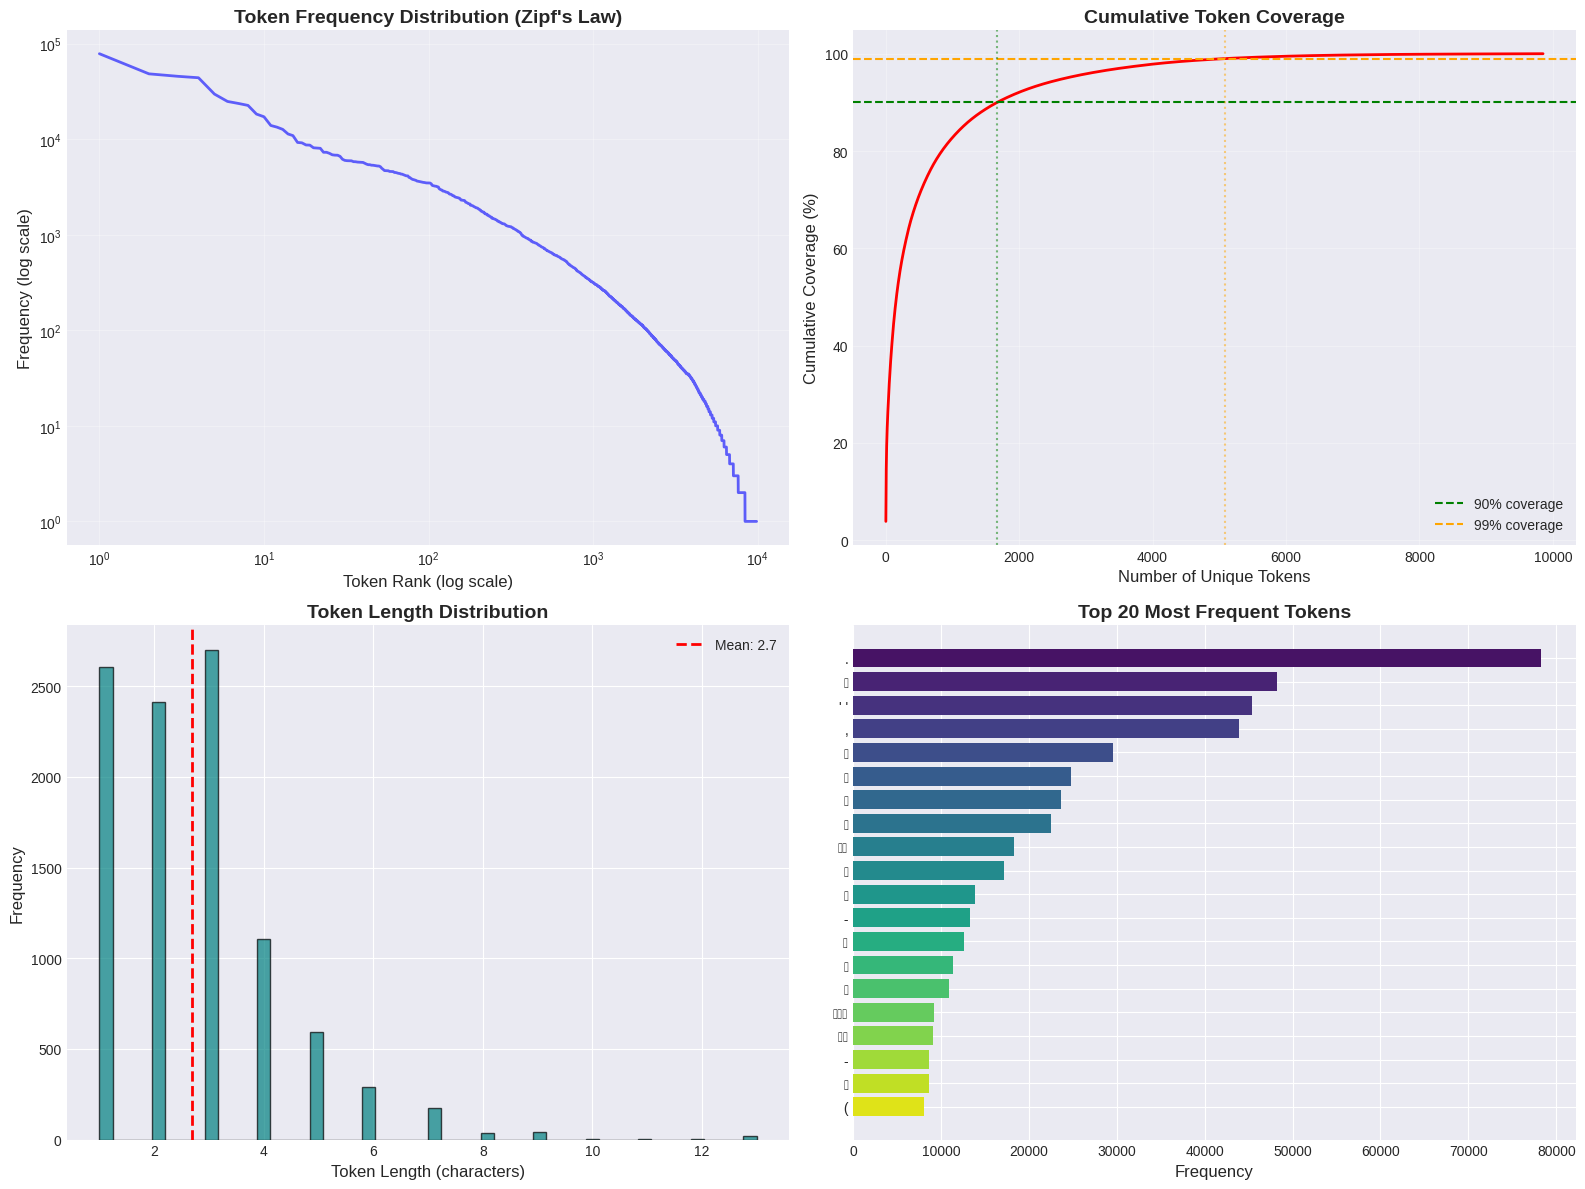


📊 VOCABULARY USAGE INSIGHTS:
  • Tokens needed for 90% coverage: 1,671
  • Tokens needed for 99% coverage: 5,087
  • Unused tokens in vocabulary: 129,483
    (92.9% of vocabulary unused)

  ✓ Corpus uses a concentrated vocabulary (90% coverage in <5k tokens)
    This is normal for domain-specific corpora


In [21]:
# Analyze token frequency distribution
print("Analyzing token usage distribution...\n")

token_frequencies = tokenization_stats['token_id_counter']
sorted_freqs = sorted(token_frequencies.values(), reverse=True)

# Calculate cumulative coverage
total_tokens = sum(sorted_freqs)
cumulative = []
running_sum = 0
for freq in sorted_freqs:
    running_sum += freq
    cumulative.append(100 * running_sum / total_tokens)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Token frequency distribution (log scale)
ax1 = axes[0, 0]
ax1.loglog(range(1, len(sorted_freqs) + 1), sorted_freqs, 'b-', alpha=0.6, linewidth=2)
ax1.set_xlabel('Token Rank (log scale)', fontsize=12)
ax1.set_ylabel('Frequency (log scale)', fontsize=12)
ax1.set_title('Token Frequency Distribution (Zipf\'s Law)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Cumulative vocabulary coverage
ax2 = axes[0, 1]
ax2.plot(range(1, len(cumulative) + 1), cumulative, 'r-', linewidth=2)
ax2.axhline(y=90, color='g', linestyle='--', label='90% coverage')
ax2.axhline(y=99, color='orange', linestyle='--', label='99% coverage')
ax2.set_xlabel('Number of Unique Tokens', fontsize=12)
ax2.set_ylabel('Cumulative Coverage (%)', fontsize=12)
ax2.set_title('Cumulative Token Coverage', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Find tokens needed for 90% and 99% coverage
tokens_90 = next(i for i, v in enumerate(cumulative, 1) if v >= 90)
tokens_99 = next(i for i, v in enumerate(cumulative, 1) if v >= 99)
ax2.axvline(x=tokens_90, color='g', linestyle=':', alpha=0.5)
ax2.axvline(x=tokens_99, color='orange', linestyle=':', alpha=0.5)

# 3. Token count histogram
ax3 = axes[1, 0]
sample_tokens = tokenization_stats['sample_tokens']
token_lengths = [len(tokenizer.decode([tid])) for tid in sample_tokens[:10000]]
ax3.hist(token_lengths, bins=50, color='teal', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Token Length (characters)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Token Length Distribution', fontsize=14, fontweight='bold')
ax3.axvline(np.mean(token_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(token_lengths):.1f}')
ax3.legend()

# 4. Top 20 most frequent tokens
ax4 = axes[1, 1]
top_20_tokens = token_frequencies.most_common(20)
token_labels = []
token_counts = []
for tid, count in top_20_tokens:
    token_str = tokenizer.decode([tid])
    # Truncate long tokens
    if len(token_str) > 10:
        token_str = token_str[:8] + '...'
    # Handle special characters
    if token_str in ['\n', ' ', '\t']:
        token_str = repr(token_str)
    token_labels.append(token_str)
    token_counts.append(count)

y_pos = np.arange(len(token_labels))
ax4.barh(y_pos, token_counts, color=sns.color_palette("viridis", len(token_labels)))
ax4.set_yticks(y_pos)
ax4.set_yticklabels(token_labels)
ax4.invert_yaxis()
ax4.set_xlabel('Frequency', fontsize=12)
ax4.set_title('Top 20 Most Frequent Tokens', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 VOCABULARY USAGE INSIGHTS:")
print(f"  • Tokens needed for 90% coverage: {tokens_90:,}")
print(f"  • Tokens needed for 99% coverage: {tokens_99:,}")
print(f"  • Unused tokens in vocabulary: {len(tokenizer) - len(token_frequencies):,}")
print(f"    ({100 * (len(tokenizer) - len(token_frequencies)) / len(tokenizer):.1f}% of vocabulary unused)")

if tokens_90 < 5000:
    print("\n  ✓ Corpus uses a concentrated vocabulary (90% coverage in <5k tokens)")
    print("    This is normal for domain-specific corpora")
elif tokens_90 < 20000:
    print("\n  ✓ Moderate vocabulary spread (90% coverage in 5k-20k tokens)")
    print("    Typical for mixed-domain or general corpora")
else:
    print("\n  ⚠ Very diverse vocabulary (90% coverage needs >20k tokens)")
    print("    Check if corpus contains multiple languages or domains")

## 8. Export Results and Summary

Save all analysis results for reference and decision-making.

In [22]:
# Create comprehensive report
report = f"""
{'='*80}
PREPROCESSING AND TOKENIZATION REPORT
{'='*80}
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Input File: {RAW_CORPUS_PATH}
Output Directory: {OUTPUT_DIR}
Tokenizer: {MODEL_NAME}
{'='*80}

## 1. PREPROCESSING RESULTS

Original corpus size: {len(raw_text):,} characters
Preprocessed corpus size: {len(preprocessed_text):,} characters
Reduction: {100 * (len(raw_text) - len(preprocessed_text)) / len(raw_text):.2f}%

Original tokens: {original_tokens:,}
Preprocessed tokens: {preprocessed_tokens:,}
Token reduction: {token_reduction_pct:.2f}%

## 2. TOKENIZATION STATISTICS

Total words (whitespace-split): {tokenization_stats['total_words']:,}
Total tokens generated: {tokenization_stats['total_tokens']:,}
Average tokens per word: {tokenization_stats['avg_tokens_per_word']:.3f}

Tokenizer vocabulary size: {len(tokenizer):,}
Unique tokens used: {tokenization_stats['unique_tokens_used']:,}
Vocabulary coverage: {tokenization_stats['vocab_coverage_pct']:.2f}%

## 3. VOCABULARY EXTENSION RECOMMENDATION

"""

# Add recommendation based on tokens per word
tpw = tokenization_stats['avg_tokens_per_word']
if tpw <= 1.5:
    report += """✅ VOCABULARY EXTENSION: NOT NEEDED

Reasoning:
- Excellent coverage with {:.3f} tokens per word
- SinLlama's vocabulary handles Buddhist Sinhala very well
- Proceeding with vocabulary extension would provide minimal benefit
- Training efficiency is already near-optimal

NEXT STEP: Proceed directly to continual pretraining
""".format(tpw)

elif tpw <= 2.5:
    report += """⚠️ VOCABULARY EXTENSION: OPTIONAL (ANALYZE FRAGMENTED WORDS)

Reasoning:
- Good coverage with {:.3f} tokens per word
- Some fragmentation present but manageable
- Decision depends on whether fragmented words are important Buddhist terms

RECOMMENDATION:
1. Review the "Top 50 Most Fragmented Words" list above
2. If top words are core Buddhist terminology → extend vocabulary
3. If top words are rare/typos → skip vocabulary extension

Expected benefit if extending: Reduce to 1.8-2.2 tokens/word
""".format(tpw)

elif tpw <= 4.0:
    report += """⚠️⚠️ VOCABULARY EXTENSION: RECOMMENDED

Reasoning:
- Moderate coverage with {:.3f} tokens per word
- Significant fragmentation detected
- Many Buddhist terms likely splitting into 4-5+ tokens
- Training efficiency would improve substantially with extension

RECOMMENDATION:
1. Add 5,000-10,000 domain-specific tokens
2. Focus on frequently fragmented Buddhist terminology
3. Use the fragmented words analysis above to guide selection

Expected benefit: Reduce to 2.0-2.8 tokens/word (~30% improvement)
""".format(tpw)

else:
    report += """❌ VOCABULARY EXTENSION: STRONGLY RECOMMENDED

Reasoning:
- Poor coverage with {:.3f} tokens per word
- Severe fragmentation - words splitting into 5-10+ tokens
- Major training efficiency impact
- SinLlama's vocabulary is not well-matched to Buddhist Sinhala

RECOMMENDATION:
1. Add 10,000-20,000 domain-specific tokens
2. Consider alternative: Use a different base model with better Sinhala coverage
3. If proceeding with SinLlama, vocabulary extension is essential

Expected benefit: Reduce to 2.5-3.5 tokens/word (~40-50% improvement)
""".format(tpw)

report += f"""
## 4. FILES GENERATED

Preprocessed corpus: {preprocessed_path}
Preprocessing stats: {stats_path}
This report: {os.path.join(OUTPUT_DIR, 'tokenization_report.txt')}

## 5. NEXT STEPS

Based on the analysis above:

IF vocabulary extension NOT needed:
  → Proceed to continual pretraining setup
  → Use preprocessed corpus at: {preprocessed_path}
  → Configure training with LoRA/PEFT for efficiency

IF vocabulary extension recommended:
  → Extract top N fragmented words (N depends on recommendation above)
  → Train new tokenizer on combined corpus (original + Buddhist)
  → Initialize embeddings for new tokens
  → Then proceed to continual pretraining

{'='*80}
END OF REPORT
{'='*80}
"""

# Save report
report_path = os.path.join(OUTPUT_DIR, 'tokenization_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(report)
print(f"\n✓ Report saved to: {report_path}")


PREPROCESSING AND TOKENIZATION REPORT
Generated: 2025-11-03 09:08:19
Input File: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/extractions/3_final_corpus/buddhist_corpus_combined_20251101_105228.txt
Output Directory: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/
Tokenizer: polyglots/SinLlama_v01

## 1. PREPROCESSING RESULTS

Original corpus size: 5,387,097 characters
Preprocessed corpus size: 5,340,601 characters
Reduction: 0.86%

Original tokens: 838,777
Preprocessed tokens: 838,772
Token reduction: 0.00%

## 2. TOKENIZATION STATISTICS

Total words (whitespace-split): 838,772
Total tokens generated: 2,020,328
Average tokens per word: 2.409

Tokenizer vocabulary size: 139,336
Unique tokens used: 9,853
Vocabulary coverage: 7.07%

## 3. VOCABULARY EXTENSION RECOMMENDATION

⚠️ VOCABULARY EXTENSION: OPTIONAL (ANALYZE FRAGMENTED WORDS)

Reasoning:
- Good coverage with 2.409 tokens per word
- Some 

In [23]:
# Export fragmented words analysis
fragmented_words_df = pd.DataFrame(fragmented_words)
fragmented_words_path = os.path.join(OUTPUT_DIR, 'fragmented_words.csv')
fragmented_words_df.to_csv(fragmented_words_path, index=False, encoding='utf-8')

print(f"✓ Fragmented words analysis saved to: {fragmented_words_path}")

# Export tokenization statistics
tokenization_stats_export = {
    'total_tokens': tokenization_stats['total_tokens'],
    'total_words': tokenization_stats['total_words'],
    'avg_tokens_per_word': tokenization_stats['avg_tokens_per_word'],
    'unique_tokens_used': tokenization_stats['unique_tokens_used'],
    'vocab_size': tokenization_stats['vocab_size'],
    'vocab_coverage_pct': tokenization_stats['vocab_coverage_pct'],
    'top_50_fragmented_words': fragmented_words
}

tokenization_stats_path = os.path.join(OUTPUT_DIR, 'tokenization_stats.json')
with open(tokenization_stats_path, 'w', encoding='utf-8') as f:
    json.dump(tokenization_stats_export, f, indent=2, ensure_ascii=False)

print(f"✓ Tokenization statistics saved to: {tokenization_stats_path}")

✓ Fragmented words analysis saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/fragmented_words.csv
✓ Tokenization statistics saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/tokenization_stats.json


## 9. Download Results

Download all generated files to your local machine.

In [24]:
from google.colab import files

print("Preparing files for download...\n")

print("1. Downloading preprocessed corpus...")
files.download(preprocessed_path)

print("2. Downloading tokenization report...")
files.download(report_path)

print("3. Downloading fragmented words analysis...")
files.download(fragmented_words_path)

print("4. Downloading tokenization statistics...")
files.download(tokenization_stats_path)

print("\n✓ All files downloaded successfully!")
print("\nFiles are also saved in your Google Drive at:")
print(f"  {OUTPUT_DIR}")

Preparing files for download...

1. Downloading preprocessed corpus...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2. Downloading tokenization report...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

4. Downloading tokenization statistics...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ All files downloaded successfully!

Files are also saved in your Google Drive at:
  /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/


## Summary and Conclusion

### What We've Accomplished:

✅ **Loaded and preprocessed** your raw Buddhist corpus  
✅ **Applied 6 preprocessing steps** to remove noise and artifacts  
✅ **Tokenized the corpus** with SinLlama tokenizer  
✅ **Analyzed vocabulary coverage** comprehensively  
✅ **Identified fragmented words** for potential vocabulary extension  
✅ **Generated detailed reports** with actionable recommendations  

### Your Preprocessed Corpus:

Your cleaned corpus is ready at: `{preprocessed_path}`

This file is:
- ✅ Unicode normalized (consistent character encoding)
- ✅ Free of control characters and PDF artifacts
- ✅ Whitespace normalized (consistent spacing)
- ✅ Headers/footers removed
- ✅ Page numbers filtered out
- ✅ Very short artifact lines removed

### Decision Time: Vocabulary Extension?

**Review your tokenization report above to decide:**

1. Check your **tokens-per-word ratio**
2. Review the **top 50 fragmented words**
3. Follow the recommendation in the report

### Next Steps:

**Option A: No Vocabulary Extension Needed**
→ Proceed directly to continual pretraining  
→ Use the preprocessed corpus as-is  
→ Set up training with LoRA/PEFT

**Option B: Vocabulary Extension Recommended**
→ Create vocabulary extension notebook (I can help!)  
→ Add domain-specific Buddhist terms  
→ Retokenize corpus with extended vocabulary  
→ Then proceed to continual pretraining

### Questions to Consider:

1. Are your top fragmented words important Buddhist terminology?
2. Do you have the compute resources for vocabulary extension?
3. Is training efficiency critical for your project timeline?

---

**🎉 Congratulations!** You've successfully preprocessed and analyzed your corpus. You now have the data and insights needed to make informed decisions about vocabulary extension and training strategy.

**Ready for the next step?** Let me know whether you want to:
1. Proceed with vocabulary extension
2. Move directly to continual pretraining setup
3. Dive deeper into any specific analysis

I'm here to help guide you through whichever path you choose! 🚀

---

**Notebook completed successfully!**